# CNC Digital Twin: Process Simulation + Sustainability Analytics
 
**Project for RPTU MEfIS Application — Digital Production Technologies**
 
This notebook implements a complete digital twin of a CNC milling operation:
 
1. **Cutting force model** (Kienzle equation) — force prediction from process parameters
2. **Tool wear evolution** (Taylor's tool life) — tool degradation tracking
3. **Energy consumption model** — kWh per part, including idle and machining
4. **Surface roughness prediction** — Ra from cutting parameters
5. **Sustainability KPIs** — CO₂, material utilization, OEE
6. **Process optimization** — find params minimizing energy + maintaining quality
 
**Industry 4.0 Concepts Demonstrated:**
- Digital twin synchronization (real vs simulated)
- Real-time KPI dashboards
- Predictive maintenance (tool wear)
- Sustainable manufacturing analytics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize_scalar
np.random.seed(42)
 
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")
print("All libraries loaded successfully")

All libraries loaded successfully


## 1. Kienzle Cutting Force Model
 
The Kienzle equation predicts main cutting force in milling:
 
$$F_c = k_{c,1.1} \cdot b \cdot h^{1-m_c}$$
 
Where:
- $F_c$ = main cutting force (N)
- $k_{c,1.1}$ = specific cutting force constant (N/mm²) — material-dependent
- $b$ = chip width (mm)
- $h$ = chip thickness (mm)
- $m_c$ = Kienzle exponent (0.2–0.4 typical)
 
Material-specific constants:
| Material | k_{c,1.1} (N/mm²) | m_c |
|----------|------------------|------|
| C45 steel | 2,100 | 0.26 |
| Aluminum 7075 | 800 | 0.20 |
| Stainless 304 | 2,500 | 0.30 |
| Titanium Ti-6Al-4V | 2,800 | 0.32 |

In [2]:
MATERIALS = {
    "C45 Steel":          {"kc11": 2100, "mc": 0.26, "rho": 7.85, "co2_kg": 1.85},
    "Aluminum 7075":      {"kc11": 800,  "mc": 0.20, "rho": 2.81, "co2_kg": 11.5},
    "Stainless 304":      {"kc11": 2500, "mc": 0.30, "rho": 8.00, "co2_kg": 6.15},
    "Titanium Ti-6Al-4V": {"kc11": 2800, "mc": 0.32, "rho": 4.43, "co2_kg": 47.3},
}
 
def kienzle_force(material, b, h):
    """Compute main cutting force using Kienzle equation."""
    p = MATERIALS[material]
    Fc = p["kc11"] * b * h ** (1 - p["mc"])
    return Fc
 
# Test for steel
b_test = 4.0  # mm
h_test = 0.15  # mm
for mat in MATERIALS:
    F = kienzle_force(mat, b_test, h_test)
    print(f"{mat:25s}: Fc = {F:.0f} N (b={b_test}mm, h={h_test}mm)")

C45 Steel                : Fc = 2063 N (b=4.0mm, h=0.15mm)
Aluminum 7075            : Fc = 701 N (b=4.0mm, h=0.15mm)
Stainless 304            : Fc = 2650 N (b=4.0mm, h=0.15mm)
Titanium Ti-6Al-4V       : Fc = 3083 N (b=4.0mm, h=0.15mm)


## 2. Taylor's Tool Life Equation
 
Tool wear evolution follows Taylor's law:
 
$$V_c \cdot T^n = C$$
 
Where:
- $V_c$ = cutting speed (m/min)
- $T$ = tool life (min)
- $n, C$ = material/tool constants
 
Higher cutting speed → shorter tool life (exponentially).
This is a key trade-off in production planning.

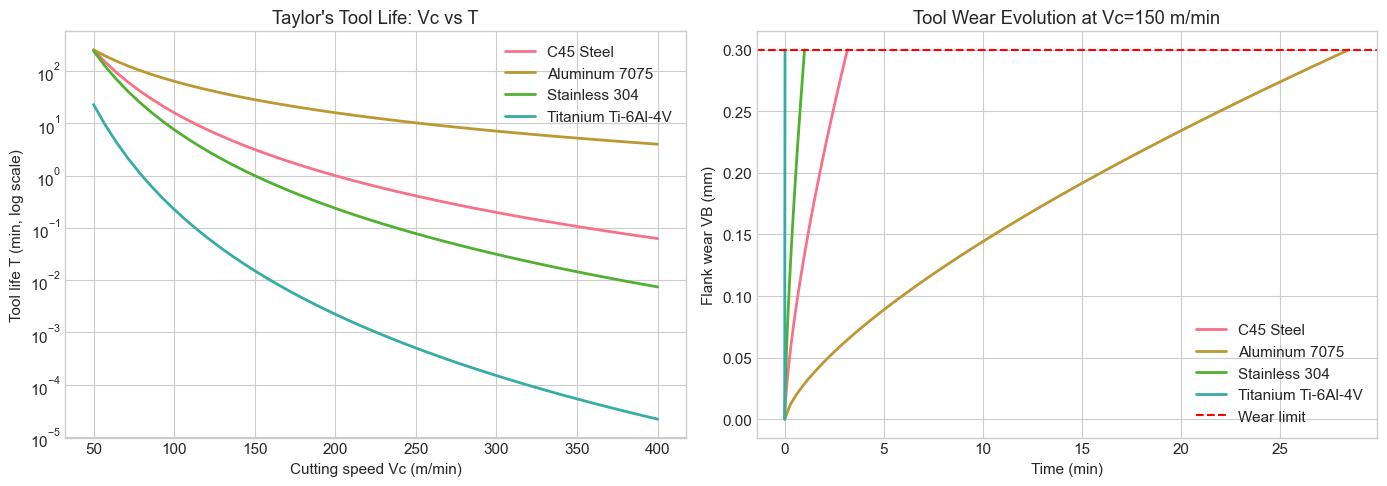

In [3]:
def taylor_tool_life(material, Vc):
    """Calculate tool life in minutes from cutting speed."""
    # Carbide tool constants
    constants = {
        "C45 Steel": (0.25, 200),
        "Aluminum 7075": (0.5, 800),
        "Stainless 304": (0.20, 150),
        "Titanium Ti-6Al-4V": (0.15, 80),
    }
    n, C = constants[material]
    T = (C / Vc) ** (1/n)
    return T
 
def tool_wear_curve(Vc_max, material, n_steps=100):
    """Generate tool wear curve over machining time."""
    T_max = taylor_tool_life(material, Vc_max)
    t = np.linspace(0, T_max, n_steps)
    # Wear follows roughly t^0.7 pattern up to wear limit (0.3mm)
    wear_limit = 0.3
    wear = wear_limit * (t / T_max) ** 0.7
    return t, wear
 
# Plot tool life vs cutting speed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
Vc_range = np.linspace(50, 400, 50)
 
for mat in MATERIALS:
    T_life = [taylor_tool_life(mat, vc) for vc in Vc_range]
    axes[0].semilogy(Vc_range, T_life, label=mat, linewidth=2)
 
axes[0].set_xlabel("Cutting speed Vc (m/min)")
axes[0].set_ylabel("Tool life T (min, log scale)")
axes[0].set_title("Taylor's Tool Life: Vc vs T")
axes[0].legend()
axes[0].grid(True)
 
# Plot wear curves at fixed Vc
for mat in MATERIALS:
    t, w = tool_wear_curve(150, mat)
    axes[1].plot(t, w, label=mat, linewidth=2)
 
axes[1].axhline(0.3, color='red', linestyle='--', label='Wear limit')
axes[1].set_xlabel("Time (min)")
axes[1].set_ylabel("Flank wear VB (mm)")
axes[1].set_title("Tool Wear Evolution at Vc=150 m/min")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [4]:
def power_consumption(material, b, h, Vc, idle_power_kw=2.0):
    """Total power: cutting + idle (machine running)."""
    Fc = kienzle_force(material, b, h)
    P_cutting = Fc * Vc / 60 / 1000  # kW
    P_total = idle_power_kw + P_cutting
    return P_total, P_cutting, idle_power_kw
 
def surface_roughness(f, r_nose):
    """Theoretical surface roughness (Ra) from feed and tool nose radius."""
    # Approximate: Ra ≈ f² / (8 * r_nose) — in micrometers
    Ra_um = (f**2 / (8 * r_nose)) * 1000  # convert mm to μm
    return Ra_um
 
def time_per_part(volume_mm3, Vc, b, h, f, n_passes=1):
    """Estimate machining time per part."""
    MRR = b * h * f * Vc * 1000 / 60  # mm³/s
    time_s = volume_mm3 / MRR * n_passes
    return time_s
 
# Demo: machining a steel block
material = "C45 Steel"
b, h, Vc, f = 4.0, 0.15, 150, 0.2
volume = 50000  # mm³
 
P_total, P_cut, P_idle = power_consumption(material, b, h, Vc)
Ra = surface_roughness(f, r_nose=0.4)
t = time_per_part(volume, Vc, b, h, f)
energy_kWh = P_total * t / 3600
 
print(f"Material: {material}")
print(f"Cutting power: {P_cut:.2f} kW")
print(f"Idle power:    {P_idle:.2f} kW")
print(f"Total power:   {P_total:.2f} kW")
print(f"Time per part: {t:.1f} s ({t/60:.2f} min)")
print(f"Energy/part:   {energy_kWh:.4f} kWh")
print(f"Surface Ra:    {Ra:.2f} μm")

Material: C45 Steel
Cutting power: 5.16 kW
Idle power:    2.00 kW
Total power:   7.16 kW
Time per part: 166.7 s (2.78 min)
Energy/part:   0.3314 kWh
Surface Ra:    12.50 μm


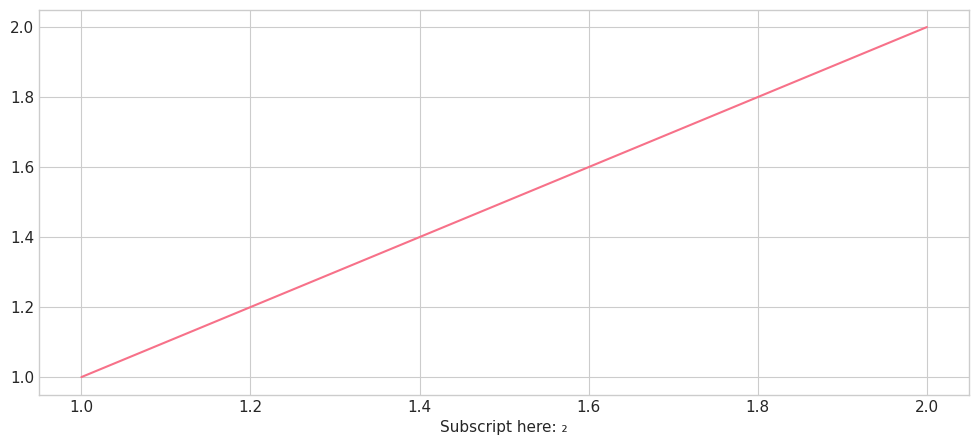

          Material  Power kW  Time/part (s)  Energy kWh/part  Mat kg/part  CO2 kg/part  Parts/tool
         C45 Steel      7.16          166.7           0.3314        0.510         1.08         1.0
     Aluminum 7075      3.75          166.7           0.1738        0.183         2.17        10.0
     Stainless 304      8.63          166.7           0.3993        0.520         3.36         0.0
Titanium Ti-6Al-4V      9.71          166.7           0.4494        0.288        13.80         0.0


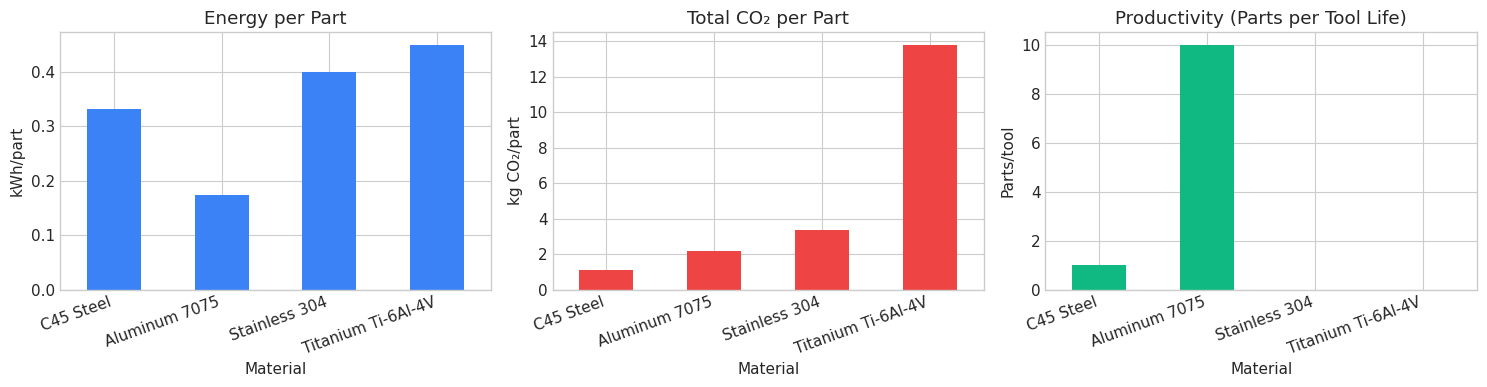

In [12]:
import matplotlib.pyplot as plt

# Set font to DejaVu Sans (which supports subscript two)
plt.rcParams['font.family'] = 'DejaVu Sans'

plt.plot([1, 2], [1, 2])
plt.xlabel("Subscript here: ₂")
plt.show()
# Compare all 4 materials with same geometry
results = []
for mat in MATERIALS:
    p = MATERIALS[mat]
    P_tot, P_cut, _ = power_consumption(mat, b, h, Vc)
    t = time_per_part(volume, Vc, b, h, f)
    energy_kWh = P_tot * t / 3600
    
    # Material consumed (assuming 30% waste -> chips)
    material_kg = volume * p["rho"] / 1e6 * 1.30
    
    # CO₂ from energy (German grid: ~0.4 kg CO₂/kWh)
    co2_energy = energy_kWh * 0.4
    # CO₂ embedded in material
    co2_material = material_kg * p["co2_kg"]
    co2_total = co2_energy + co2_material
    
    tool_life_min = taylor_tool_life(mat, Vc)
    parts_per_tool = (tool_life_min * 60) / t
    
    results.append({
        "Material": mat,
        "Power kW": round(P_tot, 2),
        "Time/part (s)": round(t, 1),
        "Energy kWh/part": round(energy_kWh, 4),
        "Mat kg/part": round(material_kg, 3),
        "CO2 kg/part": round(co2_total, 2),
        "Parts/tool": round(parts_per_tool, 0),
    })
 
df = pd.DataFrame(results)
print(df.to_string(index=False))
 
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df.plot(kind='bar', x='Material', y='Energy kWh/part', ax=axes[0], color='#3b82f6', legend=False)
axes[0].set_title("Energy per Part")
axes[0].set_ylabel("kWh/part")
 
df.plot(kind='bar', x='Material', y='CO2 kg/part', ax=axes[1], color='#ef4444', legend=False)
axes[1].set_title("Total CO₂ per Part")
axes[1].set_ylabel("kg CO₂/part")
 
df.plot(kind='bar', x='Material', y='Parts/tool', ax=axes[2], color='#10b981', legend=False)
axes[2].set_title("Productivity (Parts per Tool Life)")
axes[2].set_ylabel("Parts/tool")
 
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()


## 3. Process Optimization
 
Find the cutting speed Vc that minimizes a cost function combining:
- Energy consumption per part
- Tool wear cost (replacement cost / parts per tool)
- Time penalty (longer time = more overhead)
 
This is the classic trade-off in CNC programming: speed vs cost vs quality.

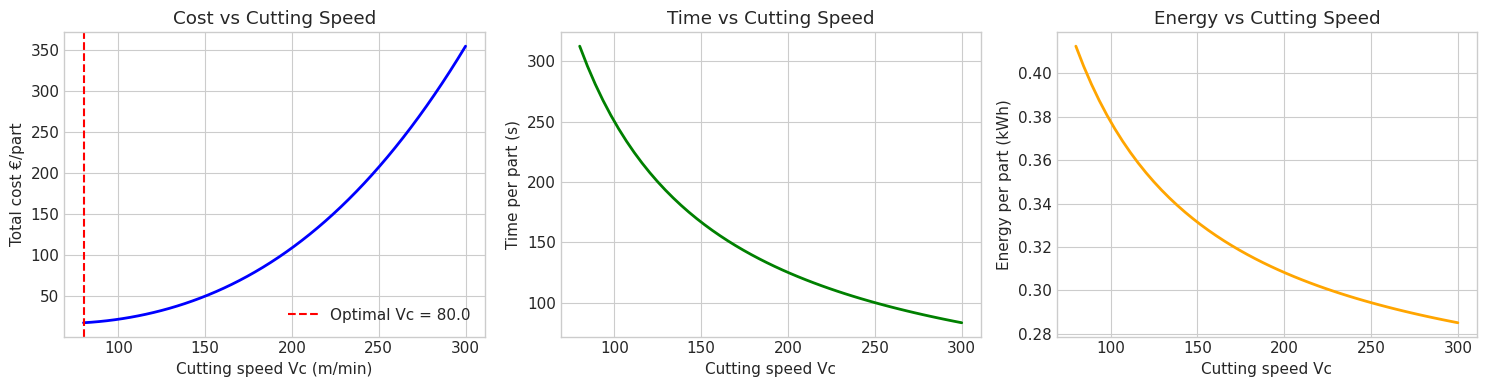


Optimal cutting speed Vc: 80.0 m/min
Minimum cost per part:    €17.207


In [13]:
def total_cost(Vc, material, b, h, f, vol, tool_cost=50, overhead_per_min=2):
    """Total cost per part: energy + tool wear + overhead time."""
    P_tot, _, _ = power_consumption(material, b, h, Vc)
    t = time_per_part(vol, Vc, b, h, f)
    energy_kWh = P_tot * t / 3600
    energy_cost = energy_kWh * 0.30  # €0.30/kWh industrial
    
    T_life_min = taylor_tool_life(material, Vc)
    parts_per_tool = (T_life_min * 60) / t
    tool_cost_per_part = tool_cost / parts_per_tool
    
    overhead_cost = (t / 60) * overhead_per_min
    
    return energy_cost + tool_cost_per_part + overhead_cost
 
# Sweep Vc and find optimum for steel
material = "C45 Steel"
Vc_range = np.linspace(80, 300, 50)
costs = [total_cost(vc, material, b, h, f, volume) for vc in Vc_range]
energy = [power_consumption(material, b, h, vc)[0] * time_per_part(volume, vc, b, h, f) / 3600 for vc in Vc_range]
times = [time_per_part(volume, vc, b, h, f) for vc in Vc_range]
 
# Find optimum
result = minimize_scalar(lambda vc: total_cost(vc, material, b, h, f, volume),
                         bounds=(80, 300), method='bounded')
Vc_opt = result.x
cost_opt = result.fun
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(Vc_range, costs, 'b-', linewidth=2)
axes[0].axvline(Vc_opt, color='r', linestyle='--', label=f'Optimal Vc = {Vc_opt:.1f}')
axes[0].set_xlabel("Cutting speed Vc (m/min)")
axes[0].set_ylabel("Total cost €/part")
axes[0].set_title("Cost vs Cutting Speed")
axes[0].legend()
axes[0].grid(True)
 
axes[1].plot(Vc_range, times, 'g-', linewidth=2)
axes[1].set_xlabel("Cutting speed Vc")
axes[1].set_ylabel("Time per part (s)")
axes[1].set_title("Time vs Cutting Speed")
axes[1].grid(True)
 
axes[2].plot(Vc_range, energy, 'orange', linewidth=2)
axes[2].set_xlabel("Cutting speed Vc")
axes[2].set_ylabel("Energy per part (kWh)")
axes[2].set_title("Energy vs Cutting Speed")
axes[2].grid(True)
 
plt.tight_layout()
plt.show()
 
print(f"\nOptimal cutting speed Vc: {Vc_opt:.1f} m/min")
print(f"Minimum cost per part:    €{cost_opt:.3f}")

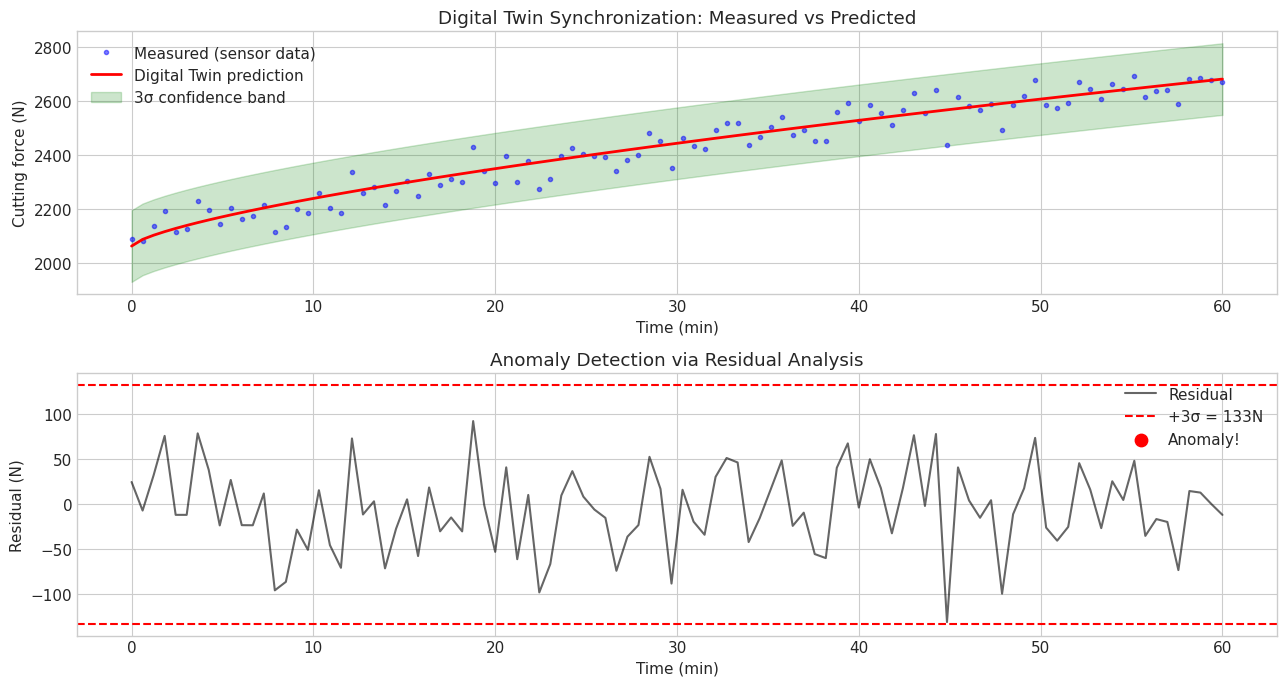

Total samples: 100
Anomalies detected: 0
Detection threshold: ±133 N


In [14]:
# Simulate "real machine" data with measurement noise + drift
np.random.seed(42)
t_real = np.linspace(0, 60, 100)  # 60 minutes
Vc_set = 150  # nominal cutting speed
 
# Simulated measured force (with noise + tool wear effect)
F_nominal = kienzle_force("C45 Steel", b, h)
wear_factor = 1 + 0.3 * (t_real / 60) ** 0.7
F_measured = F_nominal * wear_factor + np.random.normal(0, 50, len(t_real))
 
# Digital twin prediction (model)
F_predicted = F_nominal * (1 + 0.3 * (t_real / 60) ** 0.7)
 
# Detect anomaly (when measured exceeds predicted by > 3σ)
residual = F_measured - F_predicted
threshold = 3 * np.std(residual[:30])  # baseline first 30 mins
 
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
axes[0].plot(t_real, F_measured, 'b.', alpha=0.5, label='Measured (sensor data)')
axes[0].plot(t_real, F_predicted, 'r-', linewidth=2, label='Digital Twin prediction')
axes[0].fill_between(t_real, F_predicted - threshold, F_predicted + threshold, 
                     alpha=0.2, color='green', label='3σ confidence band')
axes[0].set_ylabel('Cutting force (N)')
axes[0].set_xlabel('Time (min)')
axes[0].set_title('Digital Twin Synchronization: Measured vs Predicted')
axes[0].legend()
axes[0].grid(True)
 
# Anomaly indicator
anomalies = np.abs(residual) > threshold
axes[1].plot(t_real, residual, 'k-', alpha=0.6, label='Residual')
axes[1].axhline(threshold, color='r', linestyle='--', label=f'+3σ = {threshold:.0f}N')
axes[1].axhline(-threshold, color='r', linestyle='--')
axes[1].scatter(t_real[anomalies], residual[anomalies], color='red', s=80, zorder=5, label='Anomaly!')
axes[1].set_ylabel('Residual (N)')
axes[1].set_xlabel('Time (min)')
axes[1].set_title('Anomaly Detection via Residual Analysis')
axes[1].legend()
axes[1].grid(True)
 
plt.tight_layout()
plt.show()
 
print(f"Total samples: {len(t_real)}")
print(f"Anomalies detected: {sum(anomalies)}")
print(f"Detection threshold: ±{threshold:.0f} N")

## 4. Conclusions
 
This digital twin notebook demonstrated:
 
1. **Cutting force model** (Kienzle) for 4 industrial materials
2. **Tool wear** prediction using Taylor's tool life equation
3. **Energy consumption** per part with idle + cutting power split
4. **Sustainability KPIs**: CO₂ per part, material utilization, tool productivity
5. **Process optimization**: finding cost-optimal cutting speed via SciPy
6. **Digital twin synchronization**: real-time anomaly detection from residuals
 
**Relevance to RPTU MEfIS:**
- Specialization: "Digital Production Technologies"
- Topics covered: digital modelling ✓, process simulation ✓, sustainable manufacturing ✓, Industry 4.0 ✓, digital twins ✓
 
**Future Extensions:**
- Multi-objective optimization (Pareto frontiers for energy vs quality)
- Reinforcement learning for adaptive parameter tuning
- Integration with OPC UA for real CNC machine data
- Predictive maintenance with extended Kalman filtering